# Chương 1 — Python nền tảng cho Trí tuệ kinh doanh

**Huỳnh Thái Học** — Khoa Khoa học dữ liệu trong kinh doanh, Đại học Ngân hàng

Notebook làm quen công cụ, chuẩn bị cho:

- **Chương 2:** làm sạch, tổng hợp, OLAP và dashboard mô tả;
- **Chương 3:** tạo biến, chia dữ liệu và đánh giá dự báo;
- **Chương 4:** tính giá trị kỳ vọng, ràng buộc và chọn phương án.

Đây không phải bài thực hành riêng về lý thuyết BI–BA–DSS. Tình huống ngắn chỉ
được dùng để luyện Python và tư duy **dữ liệu → phân tích → quyết định**.

> Dữ liệu mô phỏng phục vụ học tập. Trên Colab chọn **Runtime → Run all**.

## Chuẩn đầu ra

Sau notebook, sinh viên có thể:

1. Dùng biến, kiểu dữ liệu, điều kiện, vòng lặp và hàm trong Python.
2. Làm việc với `Series`/`DataFrame`, lọc và tổng hợp bằng Pandas.
3. Vẽ biểu đồ cơ bản và phân biệt mô tả với dự báo.
4. Viết phép tính giá trị kỳ vọng để chuẩn bị cho bài toán đề xuất.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_SEED = 42

## 1. Python cơ bản — biến, kiểu dữ liệu và biểu thức

Một KPI cần tên, giá trị, đơn vị và ngưỡng. Hãy chạy rồi thay đổi dữ liệu để
quan sát kết quả.

In [2]:
revenue = 125_000_000       # int
profit = 21_500_000         # int
target_margin = 0.20        # float
period = "2026-Q2"          # str

profit_margin = profit / revenue
status = "ĐẠT" if profit_margin >= target_margin else "CẢNH BÁO"

print(f"Kỳ: {period}")
print(f"Doanh thu: {revenue:,.0f} đ")
print(f"Biên lợi nhuận: {profit_margin:.1%} — {status}")

Kỳ: 2026-Q2
Doanh thu: 125,000,000 đ
Biên lợi nhuận: 17.2% — CẢNH BÁO


### Bài tập 1

Tạo biến `orders`, tính giá trị đơn hàng trung bình `revenue / orders`, sau đó
in kết quả có dấu phân cách hàng nghìn và đơn vị đồng.

In [3]:
orders = 420
average_order_value = revenue / orders
print(f"Giá trị đơn hàng trung bình: {average_order_value:,.0f} đ")
assert average_order_value > 0

Giá trị đơn hàng trung bình: 297,619 đ


## 2. List, dictionary, điều kiện và vòng lặp

`dictionary` phù hợp biểu diễn bộ KPI; vòng lặp giúp áp dụng cùng một quy tắc
cảnh báo cho nhiều chỉ số.

In [4]:
kpis = {
    "revenue_growth": 0.08,
    "profit_margin": 0.172,
    "on_time_rate": 0.91,
}
targets = {
    "revenue_growth": 0.10,
    "profit_margin": 0.20,
    "on_time_rate": 0.95,
}

for name, value in kpis.items():
    label = "ĐẠT" if value >= targets[name] else "CẦN CHÚ Ý"
    print(f"{name:18s}: {value:6.1%} | {label}")

revenue_growth    :   8.0% | CẦN CHÚ Ý
profit_margin     :  17.2% | CẦN CHÚ Ý
on_time_rate      :  91.0% | CẦN CHÚ Ý


## 3. Hàm — đóng gói logic KPI để tái sử dụng

Hàm dưới đây được dùng lại ở Chương 2 khi tổng hợp theo vùng hoặc sản phẩm.

In [5]:
def safe_margin(profit, revenue):
    # Trả về NaN nếu doanh thu bằng 0 để tránh phép chia không xác định.
    return np.nan if revenue == 0 else profit / revenue

assert np.isclose(safe_margin(20, 100), 0.2)
assert np.isnan(safe_margin(0, 0))
print(f"Biên lợi nhuận mẫu: {safe_margin(21_500_000, 125_000_000):.1%}")

Biên lợi nhuận mẫu: 17.2%


## Khối luyện tập Python cơ bản

Hãy tự viết lời giải trong các cell có nhãn `TODO` trước khi mở đáp án. Các bài
tập chỉ dùng Python chuẩn, chưa cần Pandas.

### Bài tập 2 — Biến, toán tử và định dạng

Một cửa hàng bán 125 sản phẩm với giá 80.000đ/sản phẩm, giảm giá 10% và chịu
chi phí cố định 1.500.000đ.

1. Tính doanh thu trước giảm giá.
2. Tính doanh thu thuần.
3. Tính lợi nhuận nếu giá vốn là 48.000đ/sản phẩm.
4. In kết quả có dấu phân cách hàng nghìn.

In [6]:
# TODO: thay None bằng biểu thức phù hợp.
quantity = 125
unit_price = 80_000
discount_rate = 0.10
unit_cost = 48_000
fixed_cost = 1_500_000

gross_revenue = None
net_revenue = None
total_profit = None

print("Hãy hoàn thiện gross_revenue, net_revenue và total_profit.")

Hãy hoàn thiện gross_revenue, net_revenue và total_profit.


<details><summary><b>Xem đáp án Bài tập 2</b></summary>

```python
gross_revenue = quantity * unit_price
net_revenue = gross_revenue * (1 - discount_rate)
total_profit = net_revenue - quantity * unit_cost - fixed_cost

print(f"Doanh thu trước giảm: {gross_revenue:,.0f} đ")
print(f"Doanh thu thuần: {net_revenue:,.0f} đ")
print(f"Lợi nhuận: {total_profit:,.0f} đ")
```
</details>

### Bài tập 3 — Chuỗi ký tự

Chuẩn hoá mã khách hàng `"  kh-2026-001  "` thành `"KH-2026-001"`, sau đó
tách lấy phần năm và số thứ tự.

In [7]:
raw_customer_id = "  kh-2026-001  "

# TODO: dùng strip(), upper() và split().
clean_customer_id = raw_customer_id
year = ""
sequence = ""

print(clean_customer_id, year, sequence)

  kh-2026-001    


<details><summary><b>Xem đáp án Bài tập 3</b></summary>

```python
clean_customer_id = raw_customer_id.strip().upper()
parts = clean_customer_id.split("-")
year = parts[1]
sequence = parts[2]
print(clean_customer_id, year, sequence)
```
</details>

### Bài tập 4 — List và thống kê đơn giản

Với doanh thu 7 ngày dưới đây, hãy tính tổng, trung bình, ngày cao nhất và số
ngày có doanh thu từ 12 triệu đồng trở lên. Không dùng Pandas.

In [8]:
daily_sales = [8_500_000, 12_000_000, 9_700_000, 15_200_000,
               11_300_000, 16_500_000, 13_100_000]

# TODO: dùng sum(), len(), max() và list comprehension.
total_sales = None
average_sales = None
highest_sales = None
days_above_12m = None

print("Hãy hoàn thiện bốn kết quả thống kê.")

Hãy hoàn thiện bốn kết quả thống kê.


<details><summary><b>Xem đáp án Bài tập 4</b></summary>

```python
total_sales = sum(daily_sales)
average_sales = total_sales / len(daily_sales)
highest_sales = max(daily_sales)
days_above_12m = len([value for value in daily_sales if value >= 12_000_000])
```
</details>

### Bài tập 5 — Dictionary và truy cập dữ liệu

Tính biên lợi nhuận của từng chi nhánh và tìm chi nhánh có lợi nhuận lớn nhất.

In [9]:
branches = {
    "Hà Nội": {"sales": 320_000_000, "profit": 58_000_000},
    "Đà Nẵng": {"sales": 210_000_000, "profit": 42_000_000},
    "TP.HCM": {"sales": 410_000_000, "profit": 69_000_000},
}

# TODO: duyệt dictionary và lưu biên lợi nhuận vào branch_margins.
branch_margins = {}
best_branch = ""

print("Hãy tính branch_margins và best_branch.")

Hãy tính branch_margins và best_branch.


<details><summary><b>Xem đáp án Bài tập 5</b></summary>

```python
branch_margins = {
    name: values["profit"] / values["sales"]
    for name, values in branches.items()
}
best_branch = max(branches, key=lambda name: branches[name]["profit"])
print(branch_margins)
print("Lợi nhuận cao nhất:", best_branch)
```
</details>

### Bài tập 6 — Điều kiện nhiều mức

Viết chương trình phân loại biên lợi nhuận:

- từ 20% trở lên: `Tốt`;
- từ 10% đến dưới 20%: `Theo dõi`;
- dưới 10%: `Cảnh báo`.

Kiểm tra chương trình với `margin = 0.17`.

In [10]:
margin = 0.17

# TODO: sử dụng if / elif / else.
classification = "Chưa phân loại"

print("Kết quả:", classification)

Kết quả: Chưa phân loại


<details><summary><b>Xem đáp án Bài tập 6</b></summary>

```python
if margin >= 0.20:
    classification = "Tốt"
elif margin >= 0.10:
    classification = "Theo dõi"
else:
    classification = "Cảnh báo"
```
</details>

### Bài tập 7 — Vòng lặp và bộ đếm

Đếm số giao dịch `Đạt`, `Theo dõi`, `Cảnh báo` dựa trên các biên lợi nhuận
`[0.22, 0.08, 0.15, 0.27, 0.09, 0.18]` và quy tắc ở Bài tập 6.

In [11]:
margins = [0.22, 0.08, 0.15, 0.27, 0.09, 0.18]
counts = {"Tốt": 0, "Theo dõi": 0, "Cảnh báo": 0}

# TODO: duyệt margins và tăng đúng bộ đếm trong counts.

print(counts)

{'Tốt': 0, 'Theo dõi': 0, 'Cảnh báo': 0}


<details><summary><b>Xem đáp án Bài tập 7</b></summary>

```python
for value in margins:
    if value >= 0.20:
        counts["Tốt"] += 1
    elif value >= 0.10:
        counts["Theo dõi"] += 1
    else:
        counts["Cảnh báo"] += 1
print(counts)
```
</details>

### Bài tập 8 — Viết hàm có kiểm tra đầu vào

Viết hàm `calculate_aov(revenue, orders)` tính giá trị đơn hàng trung bình.
Nếu `orders <= 0`, hàm phải trả về `None`.

In [12]:
def calculate_aov(revenue, orders):
    # TODO: hoàn thiện thân hàm.
    return None

print("AOV mẫu:", calculate_aov(120_000_000, 400))

AOV mẫu: None


<details><summary><b>Xem đáp án Bài tập 8</b></summary>

```python
def calculate_aov(revenue, orders):
    if orders <= 0:
        return None
    return revenue / orders

assert calculate_aov(120_000_000, 400) == 300_000
assert calculate_aov(120_000_000, 0) is None
```
</details>

### Bài tập 9 — Bài tổng hợp Python chuẩn

Cho danh sách đơn hàng, hãy:

1. Chỉ giữ đơn `completed`.
2. Tính tổng doanh thu hoàn tất theo vùng.
3. Tìm vùng có doanh thu hoàn tất cao nhất.

In [13]:
orders_basic = [
    {"order_id": "DH01", "region": "Bắc", "amount": 1_200_000, "status": "completed"},
    {"order_id": "DH02", "region": "Nam", "amount": 950_000, "status": "cancelled"},
    {"order_id": "DH03", "region": "Nam", "amount": 1_800_000, "status": "completed"},
    {"order_id": "DH04", "region": "Bắc", "amount": 700_000, "status": "completed"},
    {"order_id": "DH05", "region": "Trung", "amount": 1_450_000, "status": "completed"},
]

# TODO: sử dụng vòng lặp, điều kiện và dictionary.
completed_revenue = {}
best_region = ""

print("Hãy hoàn thiện completed_revenue và best_region.")

Hãy hoàn thiện completed_revenue và best_region.


<details><summary><b>Xem đáp án Bài tập 9</b></summary>

```python
completed_revenue = {}
for order in orders_basic:
    if order["status"] != "completed":
        continue
    region = order["region"]
    completed_revenue[region] = completed_revenue.get(region, 0) + order["amount"]

best_region = max(completed_revenue, key=completed_revenue.get)
print(completed_revenue)
print("Vùng cao nhất:", best_region)
```
</details>

## 4. DataFrame — nền tảng cho Chương 2

**Grain:** mỗi dòng là một giao dịch bán hàng. `region`, `month`, `category`
là dimension; `sales`, `profit` là measure.

In [14]:
rng = np.random.default_rng(RANDOM_SEED)
n = 120
sales = rng.integers(100_000, 2_000_000, n)
df = pd.DataFrame({
    "transaction_id": [f"GD{i:03d}" for i in range(1, n + 1)],
    "month": rng.choice(["2026-04", "2026-05", "2026-06"], n),
    "region": rng.choice(["Miền Bắc", "Miền Trung", "Miền Nam"], n),
    "category": rng.choice(["Đồ uống", "Thực phẩm", "Gia dụng"], n),
    "sales": sales,
    "profit": np.round(sales * rng.uniform(0.08, 0.32, n)).astype(int),
})
df.head()

,transaction_id,month,region,category,sales,profit
0,GD001,2026-05,Miền Bắc,Gia dụng,269576,75229
1,GD002,2026-06,Miền Trung,Gia dụng,1570516,425981
2,GD003,2026-05,Miền Bắc,Đồ uống,1343685,182518
3,GD004,2026-05,Miền Trung,Gia dụng,933869,193670
4,GD005,2026-06,Miền Trung,Đồ uống,922728,208023


In [15]:
# Lọc → nhóm → tổng hợp → sắp xếp
south_summary = (df.loc[df["region"].eq("Miền Nam")]
                 .groupby("category", as_index=False)
                 .agg(sales=("sales", "sum"), profit=("profit", "sum"))
                 .sort_values("sales", ascending=False))
south_summary["margin"] = south_summary["profit"] / south_summary["sales"]
south_summary

,category,sales,profit,margin
2,Đồ uống,17227370,3770687,0.218878
1,Thực phẩm,13449950,2867319,0.213184
0,Gia dụng,5900390,1280832,0.217076


### Bài tập 10 — Pandas cơ bản

1. Lọc giao dịch tháng `2026-06`.
2. Tính doanh thu và lợi nhuận theo vùng.
3. Xác định vùng có doanh thu cao nhất.
4. Giải thích vì sao bảng này là **mô tả**, chưa phải **dự báo**.

In [16]:
june = df[df["month"].eq("2026-06")]
june_by_region = (june.groupby("region", as_index=False)
                  .agg(sales=("sales", "sum"), profit=("profit", "sum"))
                  .sort_values("sales", ascending=False))
display(june_by_region)
print("Vùng doanh thu cao nhất:", june_by_region.iloc[0]["region"])

,region,sales,profit
2,Miền Trung,20069461,3790744
1,Miền Nam,16245706,3985057
0,Miền Bắc,12039932,2278706


Vùng doanh thu cao nhất: Miền Trung


## 5. Trực quan cơ bản — cầu nối sang dashboard Chương 2

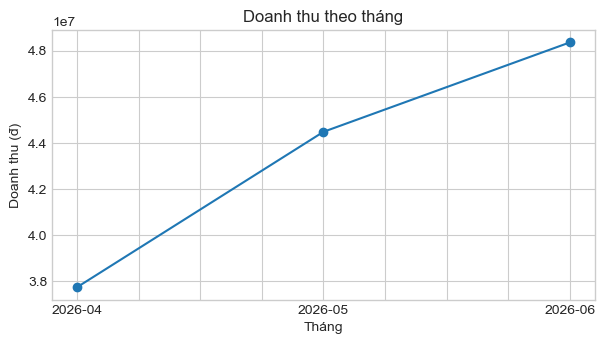

In [17]:
monthly = df.groupby("month", as_index=False)["sales"].sum().sort_values("month")
ax = monthly.plot(x="month", y="sales", marker="o", legend=False, figsize=(7, 3.5))
ax.set(title="Doanh thu theo tháng", xlabel="Tháng", ylabel="Doanh thu (đ)")
plt.show()

## 6. Tạo biến và chia dữ liệu — chuẩn bị cho Chương 3

Ở đây **chưa huấn luyện mô hình**. Ta chỉ tạo biến mục tiêu và chia tập dữ
liệu để hiểu cấu trúc một bài toán dự báo.

In [18]:
customers = pd.DataFrame({
    "tenure_months": rng.integers(1, 73, 100),
    "complaints": rng.poisson(0.7, 100),
    "monthly_fee": rng.integers(100_000, 600_000, 100),
})
customers["high_risk"] = (
    (customers["complaints"] >= 2) & (customers["tenure_months"] < 18)
).astype(int)

train = customers.sample(frac=0.8, random_state=RANDOM_SEED)
test = customers.drop(train.index)
print("Train:", train.shape, "| Test:", test.shape)
print("Tỷ lệ high_risk:", customers["high_risk"].mean().round(3))

Train: (80, 4) | Test: (20, 4)
Tỷ lệ high_risk: 0.01


**Câu hỏi kiểm tra:** Vì sao không được dùng tập test để điều chỉnh quy tắc/mô
hình? Biến `high_risk` ở ví dụ này chỉ là nhãn mô phỏng; trong thực tế cần định
nghĩa kết quả kinh doanh quan sát được.

## 7. Giá trị kỳ vọng và ràng buộc — chuẩn bị cho Chương 4

Một đề xuất không chỉ dựa vào xác suất. Ta cần kết hợp xác suất thành công,
lợi ích, chi phí và ngân sách.

In [19]:
offers = pd.DataFrame({
    "option": ["Giảm giá", "Tặng dung lượng", "Chăm sóc cá nhân"],
    "success_probability": [0.55, 0.40, 0.68],
    "benefit_if_success": [500_000, 420_000, 650_000],
    "cost": [160_000, 80_000, 260_000],
})
offers["expected_net_value"] = (
    offers["success_probability"] * offers["benefit_if_success"] - offers["cost"]
)
offers.sort_values("expected_net_value", ascending=False)

,option,success_probability,benefit_if_success,cost,expected_net_value
2,Chăm sóc cá nhân,0.68,650000,260000,182000.0
0,Giảm giá,0.55,500000,160000,115000.0
1,Tặng dung lượng,0.40,420000,80000,88000.0


### Bài tập tổng hợp

Với dữ liệu bán hàng ở phần 4:

1. Viết một câu hỏi mô tả cho Chương 2.
2. Nêu một biến mục tiêu có thể dự báo ở Chương 3.
3. Nêu hai phương án hành động và một ràng buộc cho Chương 4.
4. Chỉ rõ đầu ra Python nào sẽ hỗ trợ quyết định của nhà quản lý.

Mục tiêu là nhìn thấy vai trò liên tục của Python trong toàn bộ học phần,
không kết luận rằng một bảng thống kê tự nó đã là một quyết định.